<a href="https://colab.research.google.com/github/denverkim/DM_FALL2026/blob/main/DM_LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

butler = pd.read_excel('/content/butler.xlsx')
butler

,DrivingAssignment,MilesTraveled,NumberOfDeliveries,TravelTime
0,1,100,4,9.3
1,2,50,3,4.8
2,3,100,4,8.9
3,4,100,2,6.5
4,5,50,2,4.2
5,6,80,2,6.2
6,7,75,3,7.4
7,8,65,4,6.0
8,9,90,3,7.6
9,10,90,2,6.1


# 전처리

In [2]:
# 인덱스 재설정
butler.set_index('DrivingAssignment', inplace=True)
butler.head()

,MilesTraveled,NumberOfDeliveries,TravelTime
DrivingAssignment,,,
1,100,4,9.3
2,50,3,4.8
3,100,4,8.9
4,100,2,6.5
5,50,2,4.2


In [3]:
# 변수명 변경
butler.columns = ['운전거리', '배달갯수', '배달시간']
butler.head()

,운전거리,배달갯수,배달시간
DrivingAssignment,,,
1,100,4,9.3
2,50,3,4.8
3,100,4,8.9
4,100,2,6.5
5,50,2,4.2


In [4]:
# 한글폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/truetype/nanum
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 12 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/root/.fonts: skipping, no such directory
/u

In [ ]:
# Runtime --> Restart session

In [6]:
# 한글폰트 설정
import matplotlib as mpl

mpl.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지

# Preliminary Analysis

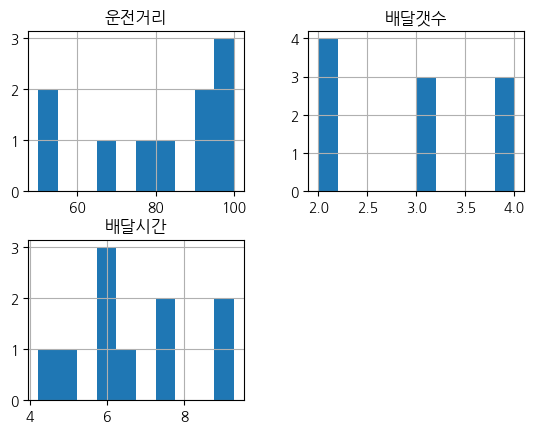

In [7]:
# 단변량 분석

import matplotlib.pyplot as plt

# 히스토그램
butler.hist()
plt.show()

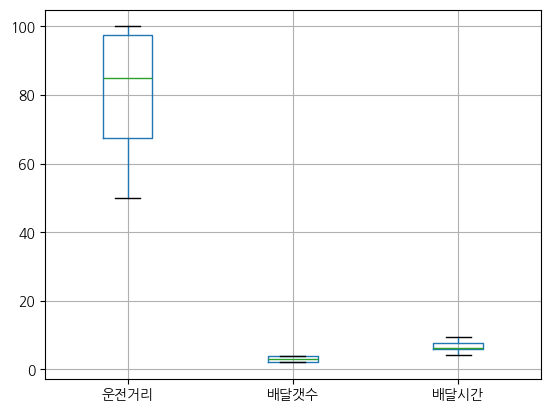

In [9]:
# 박스플랏
butler.boxplot()
plt.show()

In [10]:
# 기초 통계량
butler.describe()

,운전거리,배달갯수,배달시간
count,10.0000,10.000000,10.000000
mean,80.0000,2.900000,6.700000
std,19.5789,0.875595,1.629588
min,50.0000,2.000000,4.200000
25%,67.5000,2.000000,6.025000
50%,85.0000,3.000000,6.350000
75%,97.5000,3.750000,7.550000
max,100.0000,4.000000,9.300000


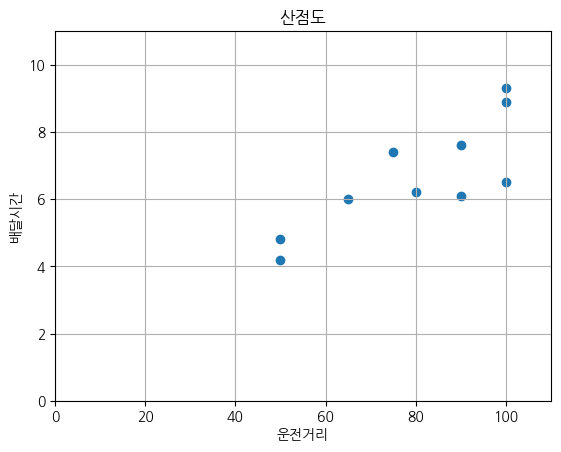

In [16]:
# 다변량 분석

# 산점도
plt.scatter(butler.운전거리, butler.배달시간)
plt.grid()
plt.xlim(0, 110)
plt.ylim(0, 11)
plt.xlabel('운전거리')
plt.ylabel('배달시간')
plt.title('산점도')
plt.show()

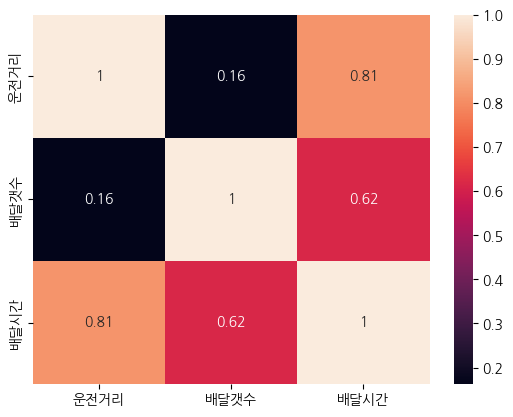

In [22]:
# 상관관계

import seaborn as sns

sns.heatmap(butler.corr(), annot=True)
plt.show()

In [21]:
# x and y split
y = butler.배달시간
x = butler.운전거리

In [23]:
# 선형 회귀분석
import statsmodels.api as sm

x = sm.add_constant(x)
x

,const,운전거리
DrivingAssignment,,
1,1.0,100
2,1.0,50
3,1.0,100
4,1.0,100
5,1.0,50
6,1.0,80
7,1.0,75
8,1.0,65
9,1.0,90


In [27]:
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   배달시간   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     15.81
Date:                Fri, 02 Oct 2026   Prob (F-statistic):            0.00408
Time:                        11:29:20   Log-Likelihood:                -13.092
No. Observations:                  10   AIC:                             30.18
Df Residuals:                       8   BIC:                             30.79
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2739      1.401      0.909      0.390      -1.956       4.504
운전거리           0.0678      0.017      3.977      0.004       0.028       0.107
==============================================================================
Omnibus:                        0.694   Durbin-Watson:                   1.723
Prob(Omnibus):                  0.707   Jarque-Bera (JB):                0.623
Skew:                          -0.333   Prob(JB):                        0.732
Kurtosis:                       1.974   Cond. No.                         363.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# 배달시간 = 1.2739 + 0.0678 * 운전거리
# R-squared:	0.664, 66%의 설명력을 갖는 모델이다.

In [29]:
# 다중회귀분석
y = butler.배달시간
x = butler[['운전거리','배달갯수']]

In [30]:
x = sm.add_constant(x)
x

,const,운전거리,배달갯수
DrivingAssignment,,,
1,1.0,100,4
2,1.0,50,3
3,1.0,100,4
4,1.0,100,2
5,1.0,50,2
6,1.0,80,2
7,1.0,75,3
8,1.0,65,4
9,1.0,90,3


In [31]:
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   배달시간   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     32.88
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           0.000276
Time:                        11:39:57   Log-Likelihood:                -6.8398
No. Observations:                  10   AIC:                             19.68
Df Residuals:                       7   BIC:                             20.59
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8687      0.952     -0.913      0.392      -3.119       1.381
운전거리           0.0611      0.010      6.182      0.000       0.038       0.085
배달갯수           0.9234      0.221      4.176      0.004       0.401       1.446
==============================================================================
Omnibus:                        0.039   Durbin-Watson:                   2.515
Prob(Omnibus):                  0.981   Jarque-Bera (JB):                0.151
Skew:                           0.074   Prob(JB):                        0.927
Kurtosis:                       2.418   Cond. No.                         435.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# 배달시간 = -0.8687 + 0.0611*운전시간 + 0.9234*배달갯수
# R-squared:	0.904, 90.4%의 설명력을 갖는 모델이다.

In [32]:
# 잔차분석
y_pred = model.predict(x)
y_pred

,0
DrivingAssignment,
1,8.938460
2,4.958305
3,8.938460
4,7.091609
5,4.034879
6,5.868917
7,6.486670
8,6.798749
9,7.403689


In [33]:
residual = y - y_pred
residual

,0
DrivingAssignment,
1,0.361540
2,-0.158305
3,-0.038460
4,-0.591609
5,0.165121
6,0.331083
7,0.913330
8,-0.798749
9,0.196311


In [34]:
import numpy as np

std_residual = residual / np.std(residual)
std_residual

,0
DrivingAssignment,
1,0.753954
2,-0.330128
3,-0.080204
4,-1.233740
5,0.344342
6,0.690439
7,1.904656
8,-1.665708
9,0.409387


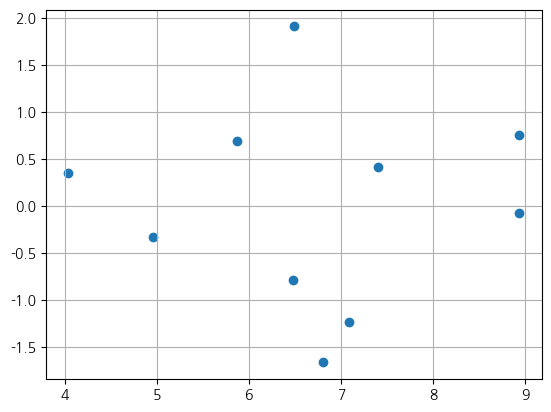

In [36]:
plt.scatter(y_pred, std_residual)
plt.grid()
plt.xlabel('y_pred')
plt.ylabel('std_residual')
plt.title('잔차분석')
plt.show()